# Dual Decoder

In [2]:
import pandas as pd
from pathlib import Path

# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt
import scanpy as sc

import InterScale as interscale
from InterScale._paths import FIG_PATH
from InterScale.config import load_config
#from InterScale.pl.wandb import load_result_as_df, compute_mean_and_std, summary_df, plot_parameter_space

## 0. Load paths

In [3]:
import os

# LRZ home
if os.path.exists("/dss/dsshome1/05/di93tig"):
    print('LRZ cluster')
    CLUSTER = 'LRZ'
    BASE_DIR_REPO = "/dss/dsshome1/05/di93tig/1_projects" 
    BASE_DIR_PROJECT = "/dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale"
elif os.path.exists("/home/icb/francesca.drummer/"):
    print('HPC cluster')
    CLUSTER = 'HPC'
    BASE_DIR_REPO = "/home/icb/francesca.drummer/1-Projects/"
    BASE_DIR_PROJECT = ""
else:
    print('unkown')
    CLUSTER = 'unknown'

LRZ cluster


In [4]:
DUAL_LEGNINI = os.path.join(BASE_DIR_PROJECT, "results/legnini23/legnini23_regr_node_44_GCN_self-attn-transformer_model.ckpt")
DUAL_MELTON = os.path.join(BASE_DIR_PROJECT, "/results/legnini23/legnini23_regr_node_44_GCN_self-attn-transformer_model.ckpt")

In [5]:
CFG_DUAL_LEGNINI = os.path.join(BASE_DIR_REPO, "GT-long-range-niches/src/config_files/Legnini23/legnini23_regr_node_DualCombined_genes.yaml")
CFG_DUAL_MELTON = os.path.join(BASE_DIR_REPO, "GT-long-range-niches/src/config_files/melton25/regr_dual_combined.yaml")

In [6]:
RESULTS_DIR = os.path.join(BASE_DIR_PROJECT, "results")

## 1. Load trained model

In [7]:
cfg = load_config(CFG_DUAL_LEGNINI)
cfg

CfgNode({'wandb': CfgNode({'use': True, 'project_name': 'GTLongRange_Legnini23'}), 'model': CfgNode({'n_embed': 16, 'local_component': CfgNode({'name': 'GCN', 'load': None, 'parameters': CfgNode({'hidden_dim': 256, 'num_layers': 2, 'dropout_local': 0.1})}), 'global_component': CfgNode({'name': 'self-attn-transformer', 'load': None, 'parameters': CfgNode({'n_heads': 4, 'dim_feedforward': 256, 'dropout_global': 0.1, 'activation_func': 'relu', 'num_layers': 2, 'max_seq_len': 4299, 'long_range_attention': False, 'type_gex_embedding': 'PCA'})}), 'save': '/dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale/results/legnini23/', 'loss': None, 'decoder': CfgNode({'type': 'linear', 'hidden_dims': [256, 128], 'dropout_decoder': 0.1, 'dual_decoder': True})}), 'optim': CfgNode({'accelerator': 'cpu', 'lr': 0.001, 'lr_scheduler': 'CosineWarmupScheduler', 'lr_warmup': 20, 'lr_max_epochs': 100, 'wd': 0.0001, 'loss': 'SmoothL1', 'seed': 44, 'cross_corr': 'cell', 'n_epochs': 100, 'e

In [8]:
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata

AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split'
    var: 'gene_ids', 'feature_types'
    obsm: 'spatial'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw'

In [9]:
model_name = "legnini23/dual_legnini23_regr_node_44_GCN_self-attn-transformer_model"

In [10]:
interscale.model.CombinedModel._setup_anndata(adata = adata, prediction_task = cfg.dataset.prediction_task, layer_key = cfg.dataset.layer_key, sample_key_list = cfg.dataset.sample_key, prediction_obs =  cfg.dataset.prediction_obs, group_key = cfg.dataset.group_label, view_registry = False)
dual_combined_model = interscale.model.CombinedModel.load(RESULTS_DIR, adata, cfg, model_name = model_name, local_component = True, global_component = True, wandb_save = True)

Loading model from /dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale/results/legnini23/dual_legnini23_regr_node_44_GCN_self-attn-transformer_modelmodel.pt
Try with .ckpt extension.
Unclear checkpoint format. Attempting remapping anyway.
State dict remapping applied. Source detected: unknown


/usr/local/lib/python3.10/dist-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[log1p_norm] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
/dss/dsshome1/05/di93tig/1_projects/GT-long-range-niches/src/InterScale/model/base/_base_model.py:598: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weight

In [11]:
print(dual_combined_model)

In [14]:
result = dual_combined_model.get_model_output(adata)

Load GEX from .layers/log1p_norm
call new


In [15]:
result

AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split', '_scvi_sample_key_0', '_scvi_group_label', '_cls_horizontal', '_cls_vertical'
    var: 'gene_ids', 'feature_types'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'spatial', '_local_emb', '_global_emb', '_attn_matrix'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw', '_y_pred_local', '_y_pred_global'

In [13]:
local_decoder_weight = dual_combined_model.module.state_dict()['local_module.decoder.decoder.weight']
global_decoder_weight = dual_combined_model.module.state_dict()['global_module.decoder.decoder.weight']

In [21]:
global_decoder_weight

tensor([[ 0.2250, -0.0410, -0.0829,  ..., -0.1766, -0.1399,  0.0829],
        [ 0.2110,  0.0827,  0.1725,  ...,  0.1079,  0.0881, -0.1901],
        [-0.0430,  0.0936, -0.0661,  ...,  0.0900,  0.1811, -0.1519],
        ...,
        [ 0.2774, -0.0060,  0.0858,  ..., -0.2661,  0.2228, -0.1966],
        [-0.0063,  0.0506,  0.1956,  ..., -0.0489,  0.1792,  0.1899],
        [ 0.1550,  0.1903, -0.1749,  ...,  0.2000, -0.0784, -0.0836]])

In [22]:
local_decoder_weight

tensor([[-0.0193,  0.0812,  0.1781,  ...,  0.0723,  0.0973,  0.1413],
        [ 0.0892, -0.0269,  0.3167,  ..., -0.0146,  0.2334,  0.1406],
        [-0.0377, -0.0646, -0.0157,  ..., -0.0517,  0.1967, -0.0939],
        ...,
        [ 0.0868, -0.1574,  0.0256,  ..., -0.1721, -0.0662,  0.0033],
        [-0.0135, -0.1442, -0.0081,  ..., -0.0017,  0.1623, -0.2344],
        [ 0.0827, -0.0095, -0.0231,  ..., -0.0242, -0.0009, -0.1859]])

In [23]:
decoder_weight

tensor([[ 0.1098,  0.1153,  0.1639,  ..., -0.2196,  0.1113, -0.0823],
        [ 0.0175,  0.1058,  0.1489,  ..., -0.0352, -0.1936,  0.1706],
        [-0.0011, -0.0703,  0.1235,  ..., -0.2355,  0.1045, -0.0509],
        ...,
        [-0.2187,  0.0319, -0.1746,  ..., -0.1629,  0.0531, -0.2206],
        [-0.2029,  0.0966, -0.1434,  ..., -0.1697,  0.0663, -0.0703],
        [ 0.1976,  0.1966,  0.0488,  ..., -0.2181,  0.2183, -0.0778]])

In [21]:
import numpy as np
np.unique(result.obs['condition'])

array(['Ctrl', 'SHH'], dtype=object)

/dss/dsshome1/05/di93tig/1_projects/GT-long-range-niches/src/InterScale/evaluation/gene_rank_analysis.py:41: RuntimeWarning: invalid value encountered in log
  r2_scores_log = [np.log(r2 + 1) for r2 in r2_scores if not np.isnan(r2)]
/dss/dsshome1/05/di93tig/1_projects/GT-long-range-niches/src/InterScale/evaluation/gene_rank_analysis.py:41: RuntimeWarning: invalid value encountered in log
  r2_scores_log = [np.log(r2 + 1) for r2 in r2_scores if not np.isnan(r2)]


Top 5 genes for _y_pred_local model:
      gene        r2    r2_log  r2_rank
47   MNX1  0.016451  0.016317     88.0
19   DLX2  0.004574  0.004564     87.0
63   OTX2 -0.001206 -0.001207     86.0
74   SIX6 -0.001528 -0.001529     85.0
25  FOXA1 -0.001985 -0.001987     84.0
Top 5 genes for _y_pred_global model:
      gene        r2    r2_log  r2_rank
60  OLIG1  0.001639  0.001637     88.0
74   SIX6 -0.001150 -0.001151     87.0
86  FOXG1 -0.002710 -0.002713     86.0
49   MSX2 -0.003430 -0.003436     85.0
28  FZD10 -0.004306 -0.004315     84.0


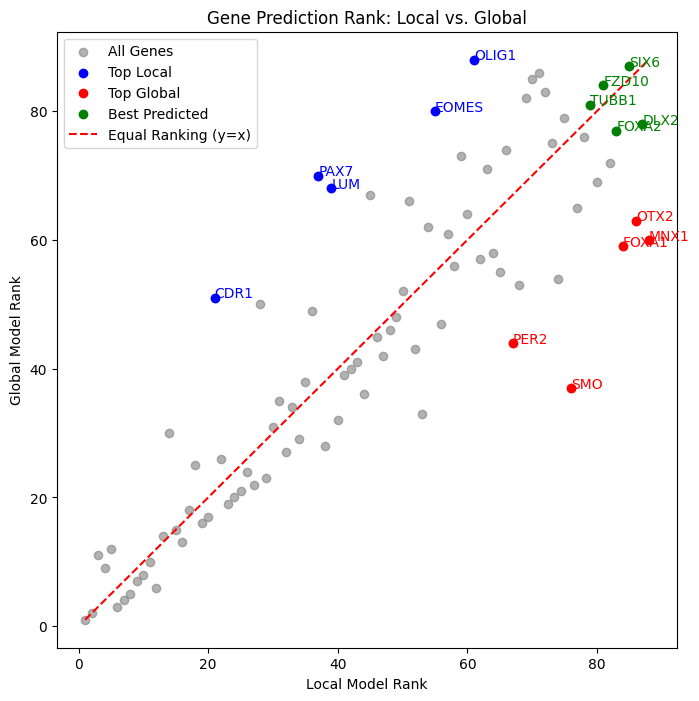

(     gene  Local Rank  Global Rank  Rank Difference  Avg Rank
 65   PAX7        37.0         70.0            -33.0      53.5
 10   CDR1        21.0         51.0            -30.0      36.0
 45    LUM        39.0         68.0            -29.0      53.5
 60  OLIG1        61.0         88.0            -27.0      74.5
 20  EOMES        55.0         80.0            -25.0      67.5,
      gene  Local Rank  Global Rank  Rank Difference  Avg Rank
 75    SMO        76.0         37.0             39.0      56.5
 47   MNX1        88.0         60.0             28.0      74.0
 25  FOXA1        84.0         59.0             25.0      71.5
 63   OTX2        86.0         63.0             23.0      74.5
 66   PER2        67.0         44.0             23.0      55.5,
      gene  Local Rank  Global Rank  Rank Difference  Avg Rank
 74   SIX6        85.0         87.0             -2.0      86.0
 19   DLX2        87.0         78.0              9.0      82.5
 28  FZD10        81.0         84.0             -3.0 

In [23]:
from InterScale.evaluation.gene_rank_analysis import predict_gene_r2, gene_rank_analysis
gene_rank_analysis(result[result.obs['condition'] =='SHH'],
                   layers_local_pred = '_y_pred_local',
                   layers_global_pred = '_y_pred_global',
                   top_n = 5,
                   plot_result = True,
                   return_top_genes = True)

/dss/dsshome1/05/di93tig/1_projects/GT-long-range-niches/src/InterScale/evaluation/gene_rank_analysis.py:41: RuntimeWarning: invalid value encountered in log
  r2_scores_log = [np.log(r2 + 1) for r2 in r2_scores if not np.isnan(r2)]
/dss/dsshome1/05/di93tig/1_projects/GT-long-range-niches/src/InterScale/evaluation/gene_rank_analysis.py:41: RuntimeWarning: invalid value encountered in log
  r2_scores_log = [np.log(r2 + 1) for r2 in r2_scores if not np.isnan(r2)]


Top 5 genes for _y_pred_local model:
       gene        r2    r2_log  r2_rank
62     OTP  0.047358  0.046271     88.0
47    MNX1  0.042032  0.041172     87.0
30    GLI1  0.030412  0.029959     86.0
54  NKX2.2  0.027658  0.027283     85.0
68  POLR1B  0.009816  0.009768     84.0
Top 5 genes for _y_pred_global model:
       gene        r2    r2_log  r2_rank
47    MNX1  0.022712  0.022458     88.0
54  NKX2.2  0.008646  0.008608     87.0
53  NKX2.1  0.000000  0.000000     85.5
87   TREM2  0.000000  0.000000     85.5
81   TUBB1 -0.002961 -0.002966     84.0


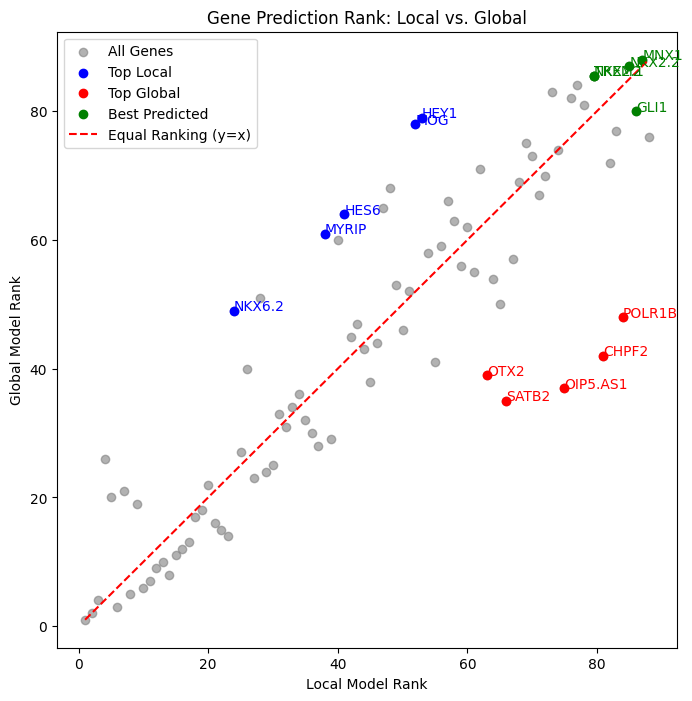

(      gene  Local Rank  Global Rank  Rank Difference  Avg Rank
 35    HEY1        53.0         79.0            -26.0      66.0
 48     MOG        52.0         78.0            -26.0      65.0
 56  NKX6.2        24.0         49.0            -25.0      36.5
 34    HES6        41.0         64.0            -23.0      52.5
 50   MYRIP        38.0         61.0            -23.0      49.5,
         gene  Local Rank  Global Rank  Rank Difference  Avg Rank
 12     CHPF2        81.0         42.0             39.0      61.5
 59  OIP5.AS1        75.0         37.0             38.0      56.0
 68    POLR1B        84.0         48.0             36.0      66.0
 72     SATB2        66.0         35.0             31.0      50.5
 63      OTX2        63.0         39.0             24.0      51.0,
       gene  Local Rank  Global Rank  Rank Difference  Avg Rank
 47    MNX1        87.0         88.0             -1.0      87.5
 54  NKX2.2        85.0         87.0             -2.0      86.0
 30    GLI1        86.0   

In [25]:
from InterScale.evaluation.gene_rank_analysis import predict_gene_r2, gene_rank_analysis
gene_rank_analysis(result[result.obs['condition'] =='Ctrl'],
                   layers_local_pred = '_y_pred_local',
                   layers_global_pred = '_y_pred_global',
                   top_n = 5,
                   plot_result = True,
                   return_top_genes = True)